In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/orvile/carotid-ultrasound-images/dataset.csv
/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/Expert mask images/202202071355560051VAS_slice_351.png
/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/Expert mask images/202201121847410041VAS_slice_614.png
/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/Expert mask images/202202071308300020EM VASCULAR_slice_695.png
/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/Expert mask images/202202071314560026VAS_slice_65.png
/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/Expert mask images/202201

In [2]:
import os

BASE = "/kaggle/input"

for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, "").count(os.sep)

    if level > 4:
        continue

    print(root)

    for f in files[:10]:
        print("  ", f)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/orvile
/kaggle/input/datasets/orvile/carotid-ultrasound-images
   dataset.csv
/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images


In [3]:
import pandas as pd

csv_path = "/kaggle/input/datasets/orvile/carotid-ultrasound-images/dataset.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

Shape: (2, 2)

Columns:
['label', 'number_of_files']

First 10 rows:


,label,number_of_files
0,Expert mask images,1100
1,US images,1100


In [4]:
import os

BASE = "/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images"

for root, dirs, files in os.walk(BASE):
    pngs = [f for f in files if f.lower().endswith(".png")]

    if pngs:
        print("\n📁", root)
        print("PNG count:", len(pngs))
        print("Examples:")
        for f in pngs[:5]:
            print(" ", f)


📁 /kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/Expert mask images
PNG count: 1100
Examples:
  202202071355560051VAS_slice_351.png
  202201121847410041VAS_slice_614.png
  202202071308300020EM VASCULAR_slice_695.png
  202202071314560026VAS_slice_65.png
  202201121823380035VAS_slice_240.png

📁 /kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/US images
PNG count: 1100
Examples:
  202202071355560051VAS_slice_351.png
  202201121847410041VAS_slice_614.png
  202202071308300020EM VASCULAR_slice_695.png
  202202071314560026VAS_slice_65.png
  202201121823380035VAS_slice_240.png


In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import cv2

# ============================================================
# PATHS
# ============================================================

BASE = "/kaggle/input/datasets/orvile/carotid-ultrasound-images/Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images"

IMG_DIR = os.path.join(BASE, "US images")
MASK_DIR = os.path.join(BASE, "Expert mask images")

IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 30
SEED = 42

# ============================================================
# MATCH IMAGE + MASK FILES
# ============================================================

image_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith(".png")
])

mask_files = set([
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith(".png")
])

pairs = [(f, f) for f in image_files if f in mask_files]

print("Matched pairs:", len(pairs))

assert len(pairs) > 0, "No matching image/mask pairs found."

# ============================================================
# LOAD DATA
# ============================================================

X = []
Y = []

for i, (img_name, mask_name) in enumerate(pairs):

    img_path = os.path.join(IMG_DIR, img_name)
    mask_path = os.path.join(MASK_DIR, mask_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Normalize ultrasound image
    img = img.astype(np.float32) / 255.0

    # Convert expert mask to binary
    mask = (mask > 0).astype(np.float32)

    X.append(img[..., None])
    Y.append(mask[..., None])

X = np.asarray(X, dtype=np.float32)
Y = np.asarray(Y, dtype=np.float32)

print("X:", X.shape)
print("Y:", Y.shape)
print("Mask values:", np.unique(Y))

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=SEED
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=SEED
)

print("\nTrain:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# ============================================================
# TF DATASETS
# ============================================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, Y_train)
).shuffle(
    len(X_train),
    seed=SEED
).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, Y_val)
).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, Y_test)
).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

# ============================================================
# DICE
# ============================================================

def dice_coef(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    smooth = 1e-6

    intersection = tf.reduce_sum(y_true * y_pred)

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# ============================================================
# IOU
# ============================================================

def iou_metric(y_true, y_pred):

    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    union = (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) -
        intersection
    )

    return (intersection + 1e-6) / (union + 1e-6)

# ============================================================
# LIGHTWEIGHT U-NET
# ============================================================

def conv_block(x, filters):

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    return x


def build_unet():

    inputs = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    )

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    c4 = conv_block(p3, 256)

    # Decoder
    u3 = layers.UpSampling2D()(c4)
    u3 = layers.Concatenate()([u3, c3])
    c5 = conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c6)
    u1 = layers.Concatenate()([u1, c1])
    c7 = conv_block(u1, 32)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c7)

    return keras.Model(inputs, outputs)


model = build_unet()

model.summary()

# ============================================================
# COMPILE
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=dice_loss,
    metrics=[
        dice_coef,
        iou_metric
    ]
)

# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_carotid_ultrasound_model.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ============================================================
# TEST
# ============================================================

print("\n========== TEST RESULTS ==========")

results = model.evaluate(
    test_ds,
    verbose=1
)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

print("\nSaved model:")
print("/kaggle/working/best_carotid_ultrasound_model.keras")

Matched pairs: 1100
X: (1100, 256, 256, 1)
Y: (1100, 256, 256, 1)
Mask values: [0. 1.]

Train: (880, 256, 256, 1)
Val: (110, 256, 256, 1)
Test: (110, 256, 256, 1)


I0000 00:00:1791357958.805264      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791357958.809239      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 1,951,937 (7.45 MB)

...

Epoch 1/30


2026-10-07 07:26:23.548853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 07:26:23.864360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 07:26:25.824344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 07:26:26.187343: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[16,192,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,128,128]{3,2,1,0}, f32[64,192,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, 

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coef: 0.1002 - iou_metric: 0.0712 - loss: 0.8998

2026-10-07 07:27:09.875862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 07:27:10.152107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_dice_coef improved from None to 0.04375, saving model to /kaggle/working/best_carotid_ultrasound_model.keras

Epoch 1: finished saving model to /kaggle/working/best_carotid_ultrasound_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 550ms/step - dice_coef: 0.1279 - iou_metric: 0.1005 - loss: 0.8721 - val_dice_coef: 0.0437 - val_iou_metric: 4.1141e-11 - val_loss: 0.9562 - learning_rate: 1.0000e-04
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - dice_coef: 0.1725 - iou_metric: 0.1492 - loss: 0.8275
Epoch 2: val_dice_coef did not improve from 0.04375
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 274ms/step - dice_coef: 0.1789 - iou_metric: 0.1555 - loss: 0.8211 - val_dice_coef: 0.0393 - val_iou_metric: 4.1141e-11 - val_loss: 0.9607 - learning_rate: 1.0000e-04
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - dice_coef: 0.1971 - iou_metric: 0.1710 - loss: 0.8029
Epoch 3: val_dice_coef did not improve from 0.04375
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 278ms/step - dice_coef: 0.2053 - iou_metric

2026-10-07 07:36:59.113642: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 07:36:59.343612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


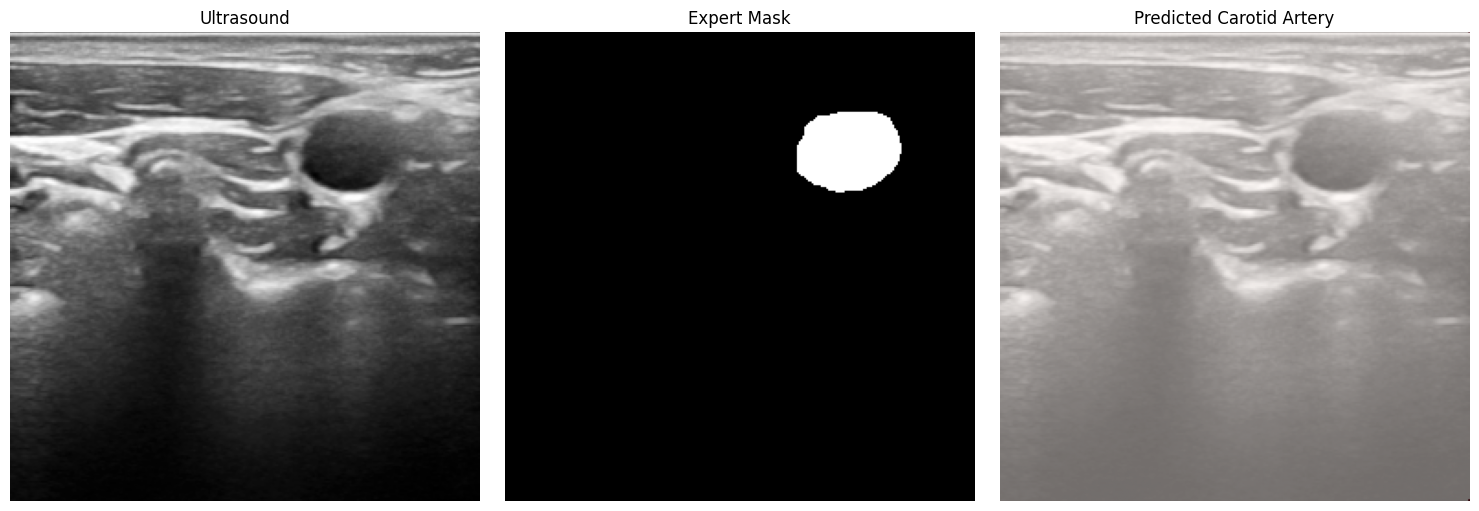

In [7]:
import matplotlib.pyplot as plt

# Load best model
best_model = tf.keras.models.load_model(
    "/kaggle/working/best_carotid_ultrasound_model.keras",
    custom_objects={
        "dice_loss": dice_loss,
        "dice_coef": dice_coef,
        "iou_metric": iou_metric
    }
)

idx = 0

image = X_test[idx]
true_mask = Y_test[idx]

pred = best_model.predict(
    image[None, ...],
    verbose=0
)[0]

pred_mask = (pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Ultrasound")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.title("Expert Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image.squeeze(), cmap="gray")
plt.imshow(
    pred_mask.squeeze(),
    cmap="Reds",
    alpha=0.45
)
plt.title("Predicted Carotid Artery")
plt.axis("off")

plt.tight_layout()
plt.show()